In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef, confusion_matrix
from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline

In [8]:
X_gen, y_gen = make_classification(
    n_samples=2000, n_features=10, n_informative=6, n_redundant=2,
    n_clusters_per_class=2, weights=[0.85, 0.15], class_sep=0.6, 
    flip_y=0.05, random_state=42
)

# Ratios a evaluar
ratios_a_probar = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

In [9]:
# Configurar la Validación Cruzada (5 pliegues, manteniendo la proporción de clases)
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Crear un "Scorer" personalizado para el MCC para que cross_validate lo entienda
mcc_scorer = make_scorer(matthews_corrcoef)

print("Iniciando Validación Cruzada Estratificada (5 Folds) para SMOTE...")

resultados_cv = []

for r in ratios_a_probar:
    # Construir el Pipeline
    # El pipeline garantiza que SMOTE solo se aplique a los datos de entrenamiento de cada fold
    modelo_pipeline = Pipeline([
        ('sampler', SMOTE(sampling_strategy=r, random_state=42)),
        ('clasificador', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1))
    ])
    
    # Ejecutar la validación cruzada
    try:
        cv_scores = cross_validate(
            modelo_pipeline, 
            X_gen, y_gen, 
            cv=cv_estrategia, 
            scoring={'MCC': mcc_scorer},
            return_train_score=False
        )
        
        # Extraer la media y la desviación estándar de los 5 pliegues
        mcc_medio = np.mean(cv_scores['test_MCC'])
        mcc_std = np.std(cv_scores['test_MCC'])
        
        resultados_cv.append({
            'Ratio': r,
            'MCC_Medio': mcc_medio,
            'MCC_Std': mcc_std
        })
        print(f"Ratio {r:.2f} -> MCC Medio: {mcc_medio:.4f} (+/- {mcc_std:.4f})")
        
    except Exception as e:
        # Pasa si SMOTE falla por un ratio inconsistente con los datos
        pass

Iniciando Validación Cruzada Estratificada (5 Folds) para SMOTE...
Ratio 0.30 -> MCC Medio: 0.6185 (+/- 0.0776)
Ratio 0.40 -> MCC Medio: 0.6275 (+/- 0.0621)
Ratio 0.50 -> MCC Medio: 0.6324 (+/- 0.0677)
Ratio 0.60 -> MCC Medio: 0.6290 (+/- 0.0811)
Ratio 0.70 -> MCC Medio: 0.6187 (+/- 0.0464)
Ratio 0.80 -> MCC Medio: 0.6433 (+/- 0.0547)
Ratio 0.90 -> MCC Medio: 0.6405 (+/- 0.0610)
Ratio 1.00 -> MCC Medio: 0.6133 (+/- 0.0550)


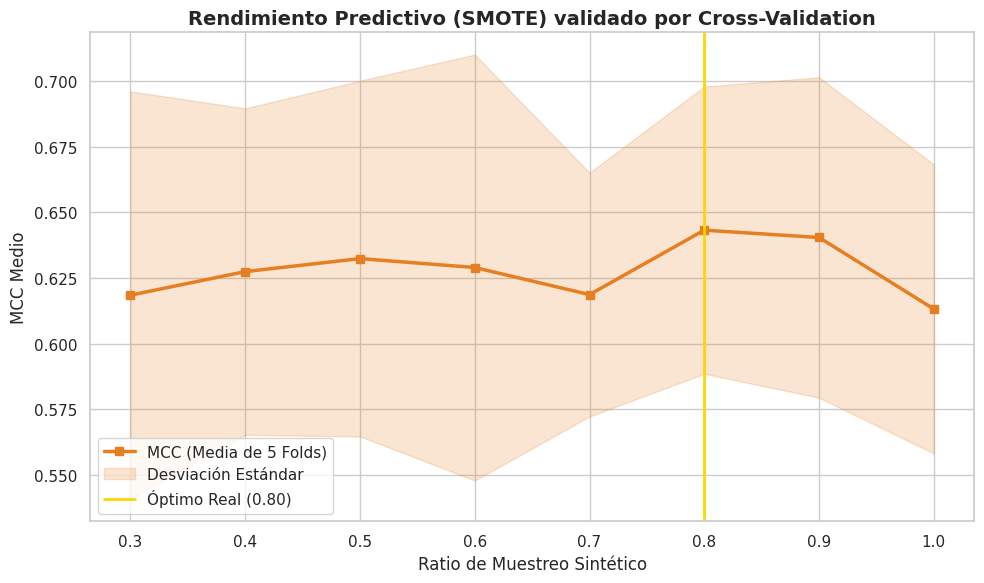

In [10]:
# Visualización con Intervalos de Confianza
df_cv = pd.DataFrame(resultados_cv)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Dibujar la línea principal (media)
plt.plot(df_cv['Ratio'], df_cv['MCC_Medio'], marker='s', color='#e67e22', linewidth=2.5, label='MCC (Media de 5 Folds)')

# Dibujar la "sombra" de la desviación estándar (la incertidumbre)
plt.fill_between(
    df_cv['Ratio'], 
    df_cv['MCC_Medio'] - df_cv['MCC_Std'], 
    df_cv['MCC_Medio'] + df_cv['MCC_Std'], 
    color='#e67e22', alpha=0.2, label='Desviación Estándar'
)

mejor_ratio = df_cv.loc[df_cv['MCC_Medio'].idxmax(), 'Ratio']
plt.axvline(x=mejor_ratio, color='gold', linestyle='-', linewidth=2, label=f'Óptimo Real ({mejor_ratio:.2f})')

plt.title('Rendimiento Predictivo (SMOTE) validado por Cross-Validation', fontsize=14, fontweight='bold')
plt.xlabel('Ratio de Muestreo Sintético', fontsize=12)
plt.ylabel('MCC Medio', fontsize=12)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()